In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*inspect a single json file's structure before the conversion...*

In [ ]:
import json

with open('/content/drive/MyDrive/autoassess_dataset/jsons/10.json') as f:
    data = json.load(f)

print(data.keys())

In [ ]:
data["shapes"][0]

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"

IMG_DIR = f"{BASE_DIR}/images"
LABEL_DIR = f"{BASE_DIR}/labels"

os.makedirs(LABEL_DIR, exist_ok=True)

In [ ]:
CLASS_MAP = {
    "door": 0,
    "bumper": 1,
    "headlight": 2,
    "fender": 3,
    "hood": 4,
    "trunk": 5,
    "mirror": 6
}

***YOLO cannot read polygon annotations, therefore build a conversion logic to convert polygons to bounding boxes...***

In [ ]:
import json

def polygon_to_bbox(points):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    return min(xs), min(ys), max(xs), max(ys)

***extract labels from the json files...***

In [ ]:
for json_file in os.listdir(f"{BASE_DIR}/jsons"):
    if not json_file.endswith(".json"):
        continue

    with open(f"{BASE_DIR}/jsons/{json_file}") as f:
        data = json.load(f)

    img_w = data["imageWidth"]
    img_h = data["imageHeight"]

    yolo_lines = []

    for shape in data["shapes"]:
        raw_label = shape["label"]

        # Extract part name
        part = raw_label.split("-")[-1].strip().lower()

        if part not in CLASS_MAP:
            continue

        class_id = CLASS_MAP[part]

        xmin, ymin, xmax, ymax = polygon_to_bbox(shape["points"])

        # YOLO normalization
        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_lines.append(
            f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}"
        )

    label_name = json_file.replace(".json", ".txt")
    with open(f"{LABEL_DIR}/{label_name}", "w") as f:
        f.write("\n".join(yolo_lines))

***extract images from the json files for the corresponding label...***

In [ ]:
import os, json, base64

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"
JSON_DIR = f"{BASE_DIR}/jsons"
IMG_DIR = f"{BASE_DIR}/images"

os.makedirs(IMG_DIR, exist_ok=True)

for json_file in os.listdir(JSON_DIR):
    if not json_file.endswith(".json"):
        continue

    with open(f"{JSON_DIR}/{json_file}") as f:
        data = json.load(f)

    if data.get("imageData") is None:
        continue

    img_bytes = base64.b64decode(data["imageData"])
    img_name = json_file.replace(".json", ".jpg")

    with open(f"{IMG_DIR}/{img_name}", "wb") as img:
        img.write(img_bytes)

print("Image extraction completed.")


Image extraction completed.


In [ ]:
len(os.listdir("/content/drive/MyDrive/autoassess_dataset/images"))

62

In [ ]:
len(os.listdir("/content/drive/MyDrive/autoassess_dataset/labels"))


63

*look for labels with no corresponding image...*

In [ ]:
import os

IMG_DIR = "/content/drive/MyDrive/autoassess_dataset/images"
LBL_DIR = "/content/drive/MyDrive/autoassess_dataset/labels"

image_files = set([f.replace(".jpg", "") for f in os.listdir(IMG_DIR)])
label_files = set([f.replace(".txt", "") for f in os.listdir(LBL_DIR)])

extra_labels = label_files - image_files
extra_images = image_files - label_files

print("Extra label files (no image):", extra_labels)
print("Extra image files (no label):", extra_images)


Extra label files (no image): {'1'}
Extra image files (no label): set()


*remove labels which has no corresponding image...*

In [ ]:
for name in extra_labels:
    os.remove(f"{LBL_DIR}/{name}.txt")

In [ ]:
print("Images:", len(os.listdir(IMG_DIR)))
print("Labels:", len(os.listdir(LBL_DIR)))

Images: 62
Labels: 62


*allocate train and val folders...*

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"

for split in ["train", "val"]:
    os.makedirs(f"{BASE_DIR}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE_DIR}/labels/{split}", exist_ok=True)

In [ ]:
import random
import shutil

IMG_SRC = f"{BASE_DIR}/images"
LBL_SRC = f"{BASE_DIR}/labels"

images = [f for f in os.listdir(IMG_SRC) if f.endswith(".jpg")]
random.shuffle(images)

split_idx = int(0.8 * len(images))
train_imgs = images[:split_idx]
val_imgs = images[split_idx:]

def move(files, img_dst, lbl_dst):
    for img in files:
        name = img.replace(".jpg", "")
        shutil.move(f"{IMG_SRC}/{img}", f"{img_dst}/{img}")
        shutil.move(f"{LBL_SRC}/{name}.txt", f"{lbl_dst}/{name}.txt")

move(train_imgs, f"{IMG_SRC}/train", f"{LBL_SRC}/train")
move(val_imgs, f"{IMG_SRC}/val", f"{LBL_SRC}/val")

print(f"Train images: {len(train_imgs)}")
print(f"Val images: {len(val_imgs)}")

Train images: 49
Val images: 13


*verify the splitting process...*

In [ ]:
print("Train images:", len(os.listdir(f"{BASE_DIR}/images/train")))
print("Val images:", len(os.listdir(f"{BASE_DIR}/images/val")))
print("Train labels:", len(os.listdir(f"{BASE_DIR}/labels/train")))
print("Val labels:", len(os.listdir(f"{BASE_DIR}/labels/val")))

Train images: 49
Val images: 13
Train labels: 49
Val labels: 13


*create dataset.yaml file...*

In [ ]:
yaml_content = f"""
path: {BASE_DIR}
train: images/train
val: images/val

names:
  0: door
  1: bumper
  2: headlight
  3: fender
  4: hood
  5: trunk
  6: mirror
"""

with open(f"{BASE_DIR}/dataset.yaml", "w") as f:
    f.write(yaml_content)

print("dataset.yaml created.")


dataset.yaml created.


In [ ]:
!cat /content/drive/MyDrive/autoassess_dataset/dataset.yaml

***dataset is cleaned and prepared for the training process...***

*install YOLOv8...*

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO
print("YOLOv8 installed successfully")

In [ ]:
!cat /content/drive/MyDrive/autoassess_dataset/dataset.yaml

*use YOLOv8n as the base architecture...*

In [ ]:
model = YOLO("yolov8n.yaml")  # architecture only, no pretrained weights

***model training...***

In [ ]:
model.train(
    data="/content/drive/MyDrive/autoassess_dataset/dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    name="autoassess_yolov8",
    device=0
)

In [ ]:
import os, shutil

BASE_DIR = "/content/drive/MyDrive/autoassess_project"
MODEL_DIR = f"{BASE_DIR}/models"

os.makedirs(MODEL_DIR, exist_ok=True)
print("Models directory ready.")

Models directory ready.


*save the base model as autoassess_yolov8_baseline.pt*

In [ ]:
src = "/content/runs/detect/autoassess_yolov8/weights/best.pt"
dst = f"{MODEL_DIR}/autoassess_yolov8_baseline.pt"

shutil.copy(src, dst)
print("Baseline model saved as autoassess_yolov8_baseline.pt")

Baseline model saved as autoassess_yolov8_baseline.pt


*save current metadata for later*

In [ ]:
meta = """
Model name: AutoAssess YOLOv8 Baseline
Architecture: YOLOv8n (from scratch)
Dataset size: 62 images
Classes: door, bumper, headlight, fender, hood, trunk, mirror
Epochs: 50
Image size: 640
Batch size: 8
Notes: Baseline model trained on limited dataset
"""

with open(f"{MODEL_DIR}/autoassess_yolov8_baseline_info.txt", "w") as f:
    f.write(meta)

print("Model metadata saved.")

Model metadata saved.


*dataset extended. confirm existence of all .jsons....*

In [ ]:
import os
print("Total JSON files:", len(os.listdir("/content/drive/MyDrive/autoassess_dataset/jsons")))

Total JSON files: 164


*re-extract all images...*

In [ ]:
import json, base64, os, shutil

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"
JSON_DIR = f"{BASE_DIR}/jsons"
IMG_DIR = f"{BASE_DIR}/images"

# Reset images folder
if os.path.exists(IMG_DIR):
    shutil.rmtree(IMG_DIR)
os.makedirs(IMG_DIR)

count = 0
for jf in os.listdir(JSON_DIR):
    if not jf.endswith(".json"):
        continue

    with open(f"{JSON_DIR}/{jf}") as f:
        data = json.load(f)

    if data.get("imageData") is None:
        continue

    img_bytes = base64.b64decode(data["imageData"])
    img_name = jf.replace(".json", ".jpg")

    with open(f"{IMG_DIR}/{img_name}", "wb") as img:
        img.write(img_bytes)
    count += 1

print("Images extracted:", count)

Images extracted: 163


*re-generate YOLO labels (polygons --> boxes)*

In [ ]:
import os, json, shutil

LBL_DIR = f"{BASE_DIR}/labels"

# Reset labels folder
if os.path.exists(LBL_DIR):
    shutil.rmtree(LBL_DIR)
os.makedirs(LBL_DIR)

CLASS_MAP = {
    "door": 0,
    "bumper": 1,
    "headlight": 2,
    "taillight": 3,
    "fender": 4,
    "hood": 5,
    "trunk": 6,
    "mirror": 7,
    "windscreen": 8
}

for jf in os.listdir(JSON_DIR):
    if not jf.endswith(".json"):
        continue

    with open(f"{JSON_DIR}/{jf}") as f:
        data = json.load(f)

    w, h = data["imageWidth"], data["imageHeight"]
    yolo_lines = []

    for shape in data["shapes"]:
        label = shape["label"]
        if label not in CLASS_MAP:
            continue

        pts = shape["points"]
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        x_c = ((x_min + x_max) / 2) / w
        y_c = ((y_min + y_max) / 2) / h
        bw = (x_max - x_min) / w
        bh = (y_max - y_min) / h

        yolo_lines.append(
            f"{CLASS_MAP[label]} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}"
        )

    with open(f"{LBL_DIR}/{jf.replace('.json', '.txt')}", "w") as out:
        out.write("\n".join(yolo_lines))

print("YOLO labels generated.")

YOLO labels generated.


*check for duplicates...*

In [ ]:
import hashlib
from collections import defaultdict

hashes = defaultdict(list)

for img in os.listdir(IMG_DIR):
    with open(f"{IMG_DIR}/{img}", "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    hashes[h].append(img)

dupes = [v for v in hashes.values() if len(v) > 1]
print("Duplicate groups:", dupes)

Duplicate groups: []


*stratified train/validation split...*

In [ ]:
import os, random, shutil
from collections import defaultdict, Counter

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"
IMG_DIR = f"{BASE_DIR}/images"
LBL_DIR = f"{BASE_DIR}/labels"

# Safety: create split dirs
for split in ["train", "val"]:
    os.makedirs(f"{IMG_DIR}/{split}", exist_ok=True)
    os.makedirs(f"{LBL_DIR}/{split}", exist_ok=True)

# Class names (for reporting only)
CLASS_NAMES = {
    0: "door",
    1: "bumper",
    2: "headlight",
    3: "taillight",
    4: "fender",
    5: "hood",
    6: "trunk",
    7: "mirror",
    8: "windscreen",
}

# Map class -> images that contain it
class_to_images = defaultdict(set)

images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")]

for img in images:
    lbl = img.replace(".jpg", ".txt")
    lbl_path = os.path.join(LBL_DIR, lbl)
    if not os.path.exists(lbl_path):
        continue
    with open(lbl_path) as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_to_images[cid].add(img)

# Pick at least ONE image per class for validation (if available)
val_images = set()
for cid, imgs in class_to_images.items():
    if imgs:
        val_images.add(random.choice(list(imgs)))

# Fill remaining validation slots to ~20%
target_val = max(len(val_images), int(0.2 * len(images)))
remaining = list(set(images) - val_images)
random.shuffle(remaining)
val_images.update(remaining[:max(0, target_val - len(val_images))])

train_images = list(set(images) - val_images)

def move(files, img_dst, lbl_dst):
    for img in files:
        name = img.replace(".jpg", "")
        shutil.move(f"{IMG_DIR}/{img}", f"{img_dst}/{img}")
        lbl_src = f"{LBL_DIR}/{name}.txt"
        if os.path.exists(lbl_src):
            shutil.move(lbl_src, f"{lbl_dst}/{name}.txt")

move(train_images, f"{IMG_DIR}/train", f"{LBL_DIR}/train")
move(list(val_images), f"{IMG_DIR}/val", f"{LBL_DIR}/val")

print("Train images:", len(train_images))
print("Val images:", len(val_images))

# --- Verify class presence in validation ---
val_counter = Counter()
for f in os.listdir(f"{LBL_DIR}/val"):
    with open(f"{LBL_DIR}/val/{f}") as fh:
        for line in fh:
            if line.strip():
                val_counter[int(line.split()[0])] += 1

print("\nValidation class distribution:")
for cid, cnt in sorted(val_counter.items()):
    print(f"{CLASS_NAMES.get(cid, cid)} → {cnt}")

Train images: 131
Val images: 32

Validation class distribution:
door → 8
bumper → 5
headlight → 3
taillight → 4
fender → 5
hood → 6
trunk → 2
mirror → 1
windscreen → 4


***re-train the model with a higher epoch value...***

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

model.train(
    data="/content/drive/MyDrive/autoassess_dataset/dataset.yaml",
    epochs=60,
    imgsz=640,
    batch=8,
    name="autoassess_yolov8_v2",
    device=0
)

In [ ]:
import shutil, os

MODEL_DIR = "/content/drive/MyDrive/autoassess_project/models"
os.makedirs(MODEL_DIR, exist_ok=True)

shutil.copy(
    "/content/runs/detect/autoassess_yolov8_v2/weights/best.pt",
    f"{MODEL_DIR}/autoassess_yolov8_improved.pt"
)

print("Improved model saved as autoassess_yolov8_improved.pt")

Improved model saved as autoassess_yolov8_improved.pt


***identified limited performance and score for the headlight, taillight, mirror, and trunk classes, therefore adding more samples to the dataset and retraining...***

In [ ]:
import os
print("Total JSON files:", len(os.listdir("/content/drive/MyDrive/autoassess_dataset/jsons")))

Total JSON files: 211


re-extract all images...

In [ ]:
import json, base64, os, shutil

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"
JSON_DIR = f"{BASE_DIR}/jsons"
IMG_DIR = f"{BASE_DIR}/images"

# Reset images folder
if os.path.exists(IMG_DIR):
    shutil.rmtree(IMG_DIR)
os.makedirs(IMG_DIR)

count = 0
for jf in os.listdir(JSON_DIR):
    if not jf.endswith(".json"):
        continue

    with open(f"{JSON_DIR}/{jf}") as f:
        data = json.load(f)

    if data.get("imageData") is None:
        continue

    img_bytes = base64.b64decode(data["imageData"])
    img_name = jf.replace(".json", ".jpg")

    with open(f"{IMG_DIR}/{img_name}", "wb") as img:
        img.write(img_bytes)
    count += 1

print("Images extracted:", count)

Images extracted: 210


re-generate YOLO labels (polygons --> boxes)

In [ ]:
import os, json, shutil

LBL_DIR = f"{BASE_DIR}/labels"

# Reset labels folder
if os.path.exists(LBL_DIR):
    shutil.rmtree(LBL_DIR)
os.makedirs(LBL_DIR)

CLASS_MAP = {
    "door": 0,
    "bumper": 1,
    "headlight": 2,
    "taillight": 3,
    "fender": 4,
    "hood": 5,
    "trunk": 6,
    "mirror": 7,
    "windscreen": 8
}

for jf in os.listdir(JSON_DIR):
    if not jf.endswith(".json"):
        continue

    with open(f"{JSON_DIR}/{jf}") as f:
        data = json.load(f)

    w, h = data["imageWidth"], data["imageHeight"]
    yolo_lines = []

    for shape in data["shapes"]:
        label = shape["label"]
        if label not in CLASS_MAP:
            continue

        pts = shape["points"]
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]

        x_min, x_max = min(xs), max(xs)
        y_min, y_max = min(ys), max(ys)

        x_c = ((x_min + x_max) / 2) / w
        y_c = ((y_min + y_max) / 2) / h
        bw = (x_max - x_min) / w
        bh = (y_max - y_min) / h

        yolo_lines.append(
            f"{CLASS_MAP[label]} {x_c:.6f} {y_c:.6f} {bw:.6f} {bh:.6f}"
        )

    with open(f"{LBL_DIR}/{jf.replace('.json', '.txt')}", "w") as out:
        out.write("\n".join(yolo_lines))

print("YOLO labels generated.")

YOLO labels generated.


check for duplicates...

In [ ]:
import hashlib
from collections import defaultdict

hashes = defaultdict(list)

for img in os.listdir(IMG_DIR):
    with open(f"{IMG_DIR}/{img}", "rb") as f:
        h = hashlib.md5(f.read()).hexdigest()
    hashes[h].append(img)

dupes = [v for v in hashes.values() if len(v) > 1]
print("Duplicate groups:", dupes)

Duplicate groups: []


stratified train/validation split...

In [ ]:
import os, random, shutil
from collections import defaultdict, Counter

BASE_DIR = "/content/drive/MyDrive/autoassess_dataset"
IMG_DIR = f"{BASE_DIR}/images"
LBL_DIR = f"{BASE_DIR}/labels"

# Safety: create split dirs
for split in ["train", "val"]:
    os.makedirs(f"{IMG_DIR}/{split}", exist_ok=True)
    os.makedirs(f"{LBL_DIR}/{split}", exist_ok=True)

# Class names (for reporting only)
CLASS_NAMES = {
    0: "door",
    1: "bumper",
    2: "headlight",
    3: "taillight",
    4: "fender",
    5: "hood",
    6: "trunk",
    7: "mirror",
    8: "windscreen",
}

# Map class -> images that contain it
class_to_images = defaultdict(set)

images = [f for f in os.listdir(IMG_DIR) if f.lower().endswith(".jpg")]

for img in images:
    lbl = img.replace(".jpg", ".txt")
    lbl_path = os.path.join(LBL_DIR, lbl)
    if not os.path.exists(lbl_path):
        continue
    with open(lbl_path) as f:
        for line in f:
            if line.strip():
                cid = int(line.split()[0])
                class_to_images[cid].add(img)

# Pick at least ONE image per class for validation (if available)
val_images = set()
for cid, imgs in class_to_images.items():
    if imgs:
        val_images.add(random.choice(list(imgs)))

# Fill remaining validation slots to ~20%
target_val = max(len(val_images), int(0.2 * len(images)))
remaining = list(set(images) - val_images)
random.shuffle(remaining)
val_images.update(remaining[:max(0, target_val - len(val_images))])

train_images = list(set(images) - val_images)

def move(files, img_dst, lbl_dst):
    for img in files:
        name = img.replace(".jpg", "")
        shutil.move(f"{IMG_DIR}/{img}", f"{img_dst}/{img}")
        lbl_src = f"{LBL_DIR}/{name}.txt"
        if os.path.exists(lbl_src):
            shutil.move(lbl_src, f"{lbl_dst}/{name}.txt")

move(train_images, f"{IMG_DIR}/train", f"{LBL_DIR}/train")
move(list(val_images), f"{IMG_DIR}/val", f"{LBL_DIR}/val")

print("Train images:", len(train_images))
print("Val images:", len(val_images))

# --- Verify class presence in validation ---
val_counter = Counter()
for f in os.listdir(f"{LBL_DIR}/val"):
    with open(f"{LBL_DIR}/val/{f}") as fh:
        for line in fh:
            if line.strip():
                val_counter[int(line.split()[0])] += 1

print("\nValidation class distribution:")
for cid, cnt in sorted(val_counter.items()):
    print(f"{CLASS_NAMES.get(cid, cid)} → {cnt}")

Train images: 168
Val images: 42

Validation class distribution:
door → 2
bumper → 7
headlight → 5
taillight → 8
fender → 5
hood → 4
trunk → 5
mirror → 1
windscreen → 5


re-train the model...

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")

model.train(
    data="/content/drive/MyDrive/autoassess_dataset/dataset.yaml",
    epochs=60,
    imgsz=640,
    batch=8,
    name="autoassess_yolov8_v2",
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/autoassess_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c523f03ab40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

In [ ]:
import shutil, os

MODEL_DIR = "/content/drive/MyDrive/autoassess_project/models"
os.makedirs(MODEL_DIR, exist_ok=True)

shutil.copy(
    "/content/runs/detect/autoassess_yolov8_v2/weights/best.pt",
    f"{MODEL_DIR}/autoassess_yolov8_improved_attempt_2.pt"
)

print("Improved model saved as autoassess_yolov8_improved_attempt_2.pt")

Improved model saved as autoassess_yolov8_improved_attempt_2.pt


***the metrics are lower due to class imbalances, therefore strictly perform a manual validation split/selection...***

*inspect labels to find images per class...*

In [ ]:
import os
from collections import defaultdict

BASE = "/content/drive/MyDrive/autoassess_dataset"
LABEL_DIRS = [
    f"{BASE}/labels/train",
    f"{BASE}/labels/val"
]

class_map = {
    0: "door",
    1: "bumper",
    2: "headlight",
    3: "taillight",
    4: "fender",
    5: "hood",
    6: "trunk",
    7: "mirror",
    8: "windscreen"
}

images_by_class = defaultdict(set)

for lbl_dir in LABEL_DIRS:
    if not os.path.exists(lbl_dir):
        continue

    for lbl in os.listdir(lbl_dir):
        if not lbl.endswith(".txt"):
            continue

        with open(f"{lbl_dir}/{lbl}") as f:
            classes = set(int(line.split()[0]) for line in f if line.strip())

        for c in classes:
            images_by_class[c].add(lbl.replace(".txt", ".jpg"))

# Print results
for c in sorted(images_by_class.keys()):
    print(f"{class_map[c]} → {len(images_by_class[c])} images")

door → 14 images
bumper → 15 images
headlight → 20 images
taillight → 24 images
fender → 13 images
hood → 16 images
trunk → 20 images
mirror → 21 images
windscreen → 29 images


*create clean folders ready to move...*

In [ ]:
import os

BASE = "/content/drive/MyDrive/autoassess_dataset"
os.makedirs(f"{BASE}/images/val", exist_ok=True)
os.makedirs(f"{BASE}/labels/val", exist_ok=True)
os.makedirs(f"{BASE}/images/train", exist_ok=True)
os.makedirs(f"{BASE}/labels/train", exist_ok=True)

In [ ]:
import os
from collections import defaultdict

BASE = "/content/drive/MyDrive/autoassess_dataset"
LABEL_DIRS = [
    f"{BASE}/labels/train",
    f"{BASE}/labels/val"
]

class_map = {
    0: "door",
    1: "bumper",
    2: "headlight",
    3: "taillight",
    4: "fender",
    5: "hood",
    6: "trunk",
    7: "mirror",
    8: "windscreen"
}

image_classes = defaultdict(set)

for lbl_dir in LABEL_DIRS:
    if not os.path.exists(lbl_dir):
        continue

    for lbl in os.listdir(lbl_dir):
        if not lbl.endswith(".txt"):
            continue

        with open(f"{lbl_dir}/{lbl}") as f:
            classes = set(int(line.split()[0]) for line in f if line.strip())

        image_classes[lbl.replace(".txt", ".jpg")] |= classes

print("Total images mapped:", len(image_classes))

Total images mapped: 210


*find good canditates (fewer classes per image, grouped in alphabetical order...)*

In [ ]:
for cid, cname in class_map.items():
    candidates = [
        img for img, classes in image_classes.items()
        if cid in classes
    ]

    # Sort by number of classes (ascending = cleaner)
    candidates = sorted(candidates, key=lambda x: len(image_classes[x]))

    print(f"\nClass: {cname} (showing up to 10 candidates)")
    for img in candidates[:10]:
        cls_list = [class_map[c] for c in image_classes[img]]
        print(f"  {img} → {cls_list}")


Class: door (showing up to 10 candidates)
  110.jpg → ['door']
  119.jpg → ['door']
  129.jpg → ['door']
  154.jpg → ['door']
  155.jpg → ['door']
  156.jpg → ['door']
  157.jpg → ['door']
  158.jpg → ['door']
  177.jpg → ['door']
  179.jpg → ['door']

Class: bumper (showing up to 10 candidates)
  122.jpg → ['bumper']
  131.jpg → ['bumper']
  162.jpg → ['bumper']
  168.jpg → ['bumper']
  169.jpg → ['bumper']
  89.jpg → ['bumper']
  130.jpg → ['bumper']
  81.jpg → ['bumper', 'trunk']
  132.jpg → ['bumper', 'trunk']
  178.jpg → ['bumper', 'fender']

Class: headlight (showing up to 10 candidates)
  84.jpg → ['headlight']
  87.jpg → ['headlight']
  102.jpg → ['headlight']
  120.jpg → ['headlight']
  121.jpg → ['headlight']
  194.jpg → ['headlight']
  189.jpg → ['headlight']
  223.jpg → ['headlight']
  216.jpg → ['headlight']
  185.jpg → ['headlight']

Class: taillight (showing up to 10 candidates)
  103.jpg → ['taillight']
  105.jpg → ['taillight']
  117.jpg → ['taillight']
  134.jpg → ['

*spread the chosen images equally to val folder...*

In [ ]:
import shutil, os

BASE = "/content/drive/MyDrive/autoassess_dataset"

VAL_IMAGES = [
    "110.jpg","119.jpg","154.jpg","177.jpg",
    "122.jpg","131.jpg","162.jpg","168.jpg",
    "84.jpg","87.jpg","102.jpg","120.jpg","121.jpg",
    "103.jpg","105.jpg","117.jpg","134.jpg","167.jpg",
    "96.jpg","97.jpg","123.jpg","165.jpg",
    "91.jpg","116.jpg","124.jpg","126.jpg",
    "93.jpg","125.jpg","209.jpg","214.jpg","213.jpg",
    "95.jpg","114.jpg","138.jpg","139.jpg","159.jpg",
    "82.jpg","85.jpg","86.jpg","90.jpg","100.jpg"
]

for img in VAL_IMAGES:
    name = img.replace(".jpg", "")
    if os.path.exists(f"{BASE}/images/{img}"):
        shutil.move(f"{BASE}/images/{img}", f"{BASE}/images/val/{img}")
    if os.path.exists(f"{BASE}/labels/{name}.txt"):
        shutil.move(f"{BASE}/labels/{name}.txt", f"{BASE}/labels/val/{name}.txt")

print("Validation images moved successfully.")

Validation images moved successfully.


*move rest of the images to train folder...*

In [ ]:
for img in os.listdir(f"{BASE}/images"):
    if img.endswith(".jpg"):
        shutil.move(f"{BASE}/images/{img}", f"{BASE}/images/train/{img}")

for lbl in os.listdir(f"{BASE}/labels"):
    if lbl.endswith(".txt"):
        shutil.move(f"{BASE}/labels/{lbl}", f"{BASE}/labels/train/{lbl}")

print("Training set prepared.")

Training set prepared.


*verify for balanced classes...*

In [ ]:
from collections import Counter

class_map = {
    0: "door", 1: "bumper", 2: "headlight", 3: "taillight",
    4: "fender", 5: "hood", 6: "trunk", 7: "mirror", 8: "windscreen"
}

counter = Counter()

for f in os.listdir(f"{BASE}/labels/val"):
    with open(f"{BASE}/labels/val/{f}") as fh:
        for line in fh:
            counter[int(line.split()[0])] += 1

print("Final validation distribution:")
for cid in sorted(counter):
    print(class_map[cid], "→", counter[cid])

Final validation distribution:
door → 4
bumper → 6
headlight → 5
taillight → 5
fender → 4
hood → 6
trunk → 5
mirror → 5
windscreen → 5


*re-train the model...*

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.yaml")  # from scratch

model.train(
    data="/content/drive/MyDrive/autoassess_dataset/dataset.yaml",
    epochs=80,
    imgsz=640,
    batch=8,
    name="autoassess_yolov8_final",
    device=0
)

Ultralytics 8.3.241 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/autoassess_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=False, name=autoassess_yolov8_final, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patienc

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7, 8])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c52ed9affb0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.0470

*save the final model...*

In [ ]:
import os, shutil

runs_dir = "/content/runs/detect"
latest_run = sorted(os.listdir(runs_dir))[-1]

print("Saving from:", latest_run)

src = f"{runs_dir}/{latest_run}/weights/best.pt"
dst = "/content/drive/MyDrive/autoassess_project/models/autoassess_yolov8_final.pt"

os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copy(src, dst)

print("Final model saved to Google Drive.")

Saving from: autoassess_yolov8_v2
Final model saved to Google Drive.


***test model on new images...***

*load the model...*

In [ ]:
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/autoassess_project/models/autoassess_yolov8_final.pt")
print("Final model loaded successfully.")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Final model loaded successfully.


In [ ]:
result = model(
    "/content/drive/MyDrive/autoassess_test_images/images.jpeg",
    conf=0.4,
    imgsz=640,
    save=True
)


image 1/1 /content/drive/MyDrive/autoassess_test_images/images.jpeg: 480x640 3 windscreens, 141.5ms
Speed: 2.5ms preprocess, 141.5ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)
Results saved to /content/runs/detect/predict


*YOLO will be saving the prediction as an image file. preview that image...*

(np.float64(-0.5), np.float64(262.5), np.float64(191.5), np.float64(-0.5))

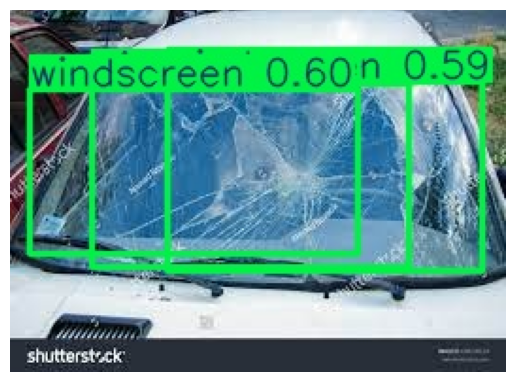

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/runs/detect/predict/images.jpg")
plt.imshow(img)
plt.axis("off")

*more test images were uploaded to the autoassess_test_images folder, run predictions on all of them...*

In [ ]:
model(
    "/content/drive/MyDrive/autoassess_test_images/",
    conf=0.4,
    imgsz=640,
    save=True
)


image 1/12 /content/drive/MyDrive/autoassess_test_images/1000_F_269321057_qyx5EswBVYWpimCljANZPpRgLJRGLxx1.jpg: 448x640 (no detections), 148.7ms
image 2/12 /content/drive/MyDrive/autoassess_test_images/car-crash-and-car-damage-body-work-and-bumper-RNGJ41.jpg: 480x640 (no detections), 157.0ms
image 3/12 /content/drive/MyDrive/autoassess_test_images/car-crash-and-car-damage-white-vehicle-rear-bumper-damage-RNGMFE.jpg: 480x640 (no detections), 234.4ms
image 4/12 /content/drive/MyDrive/autoassess_test_images/close-up-of-a-broken-tail-light-of-a-passenger-vehicle-car-2J5JJ8A.jpg: 448x640 (no detections), 161.4ms
image 5/12 /content/drive/MyDrive/autoassess_test_images/gettyimages-1066767430-612x612.jpg: 448x640 (no detections), 145.2ms
image 6/12 /content/drive/MyDrive/autoassess_test_images/gettyimages-143402900-612x612.jpg: 512x640 (no detections), 170.8ms
image 7/12 /content/drive/MyDrive/autoassess_test_images/gettyimages-990565898-612x612.jpg: 448x640 (no detections), 137.0ms
image 8/

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'door', 1: 'bumper', 2: 'headlight', 3: 'taillight', 4: 'fender', 5: 'hood', 6: 'trunk', 7: 'mirror', 8: 'windscreen'}
 obb: None
 orig_img: array([[[255, 255, 254],
         [254, 255, 253],
         [255, 255, 255],
         ...,
         [ 66,  77,  75],
         [ 35,  52,  65],
         [ 22,  46,  44]],
 
        [[231, 230, 232],
         [228, 227, 229],
         [224, 223, 225],
         ...,
         [ 40,  54,  60],
         [ 42,  55,  69],
         [ 17,  45,  52]],
 
        [[132, 133, 137],
         [125, 126, 130],
         [127, 127, 133],
         ...,
         [ 19,  41,  53],
         [ 37,  52,  61],
         [ 32,  54,  65]],
 
        ...,
 
        [[  7,   7,  13],
         [  3,   4,   8],
         [ 11,  13,  14],
         ...,
         [174, 191, 212],
         [180, 197, 218],
         [152, 169, 190]],
 
 

*test with different confidence scores and NMS...*

In [ ]:
model(
    "/content/drive/MyDrive/autoassess_test_images/",
    conf=0.25,
    imgsz=640,
    save=True
)

In [ ]:
result = model(
    "/content/drive/MyDrive/autoassess_test_images/cropped.jpg",
    conf=0.25,
    imgsz=640,
    save=True
)


image 1/1 /content/drive/MyDrive/autoassess_test_images/cropped.jpg: 448x640 (no detections), 150.8ms
Speed: 3.1ms preprocess, 150.8ms inference, 0.5ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


In [ ]:
model(
    "/content/drive/MyDrive/autoassess_test_images/",
    conf=0.25,      # VERY LOW
    iou=0.4,        # VERY HIGH (disable suppression)
    imgsz=640,
    save=True,
    verbose=True
)


image 1/13 /content/drive/MyDrive/autoassess_test_images/1000_F_269321057_qyx5EswBVYWpimCljANZPpRgLJRGLxx1.jpg: 448x640 (no detections), 253.4ms
image 2/13 /content/drive/MyDrive/autoassess_test_images/car-crash-and-car-damage-body-work-and-bumper-RNGJ41.jpg: 480x640 (no detections), 510.5ms
image 3/13 /content/drive/MyDrive/autoassess_test_images/car-crash-and-car-damage-white-vehicle-rear-bumper-damage-RNGMFE.jpg: 480x640 (no detections), 149.3ms
image 4/13 /content/drive/MyDrive/autoassess_test_images/close-up-of-a-broken-tail-light-of-a-passenger-vehicle-car-2J5JJ8A.jpg: 448x640 (no detections), 134.6ms
image 5/13 /content/drive/MyDrive/autoassess_test_images/cropped.jpg: 448x640 (no detections), 150.3ms
image 6/13 /content/drive/MyDrive/autoassess_test_images/gettyimages-1066767430-612x612.jpg: 448x640 (no detections), 140.7ms
image 7/13 /content/drive/MyDrive/autoassess_test_images/gettyimages-143402900-612x612.jpg: 512x640 (no detections), 173.3ms
image 8/13 /content/drive/MyDr

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'door', 1: 'bumper', 2: 'headlight', 3: 'taillight', 4: 'fender', 5: 'hood', 6: 'trunk', 7: 'mirror', 8: 'windscreen'}
 obb: None
 orig_img: array([[[255, 255, 254],
         [254, 255, 253],
         [255, 255, 255],
         ...,
         [ 66,  77,  75],
         [ 35,  52,  65],
         [ 22,  46,  44]],
 
        [[231, 230, 232],
         [228, 227, 229],
         [224, 223, 225],
         ...,
         [ 40,  54,  60],
         [ 42,  55,  69],
         [ 17,  45,  52]],
 
        [[132, 133, 137],
         [125, 126, 130],
         [127, 127, 133],
         ...,
         [ 19,  41,  53],
         [ 37,  52,  61],
         [ 32,  54,  65]],
 
        ...,
 
        [[  7,   7,  13],
         [  3,   4,   8],
         [ 11,  13,  14],
         ...,
         [174, 191, 212],
         [180, 197, 218],
         [152, 169, 190]],
 
 

In [ ]:
model(
    "/content/drive/MyDrive/autoassess_test_images/",
    conf=0.25,
    iou=0.6,
    imgsz=640,
    save=True,
    verbose=True
)